In [11]:
import pyxdf
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
# Load the XDF file
file_path = '/Users/debbiehsu/Downloads/run2.xdf'  # Replace with your file path
streams, header = pyxdf.load_xdf(file_path)

In [13]:
# Identify and extract the marker stream
marker_stream = None
for stream in streams:
    if stream['info']['name'][0] == 'VideoMarkers':  # Adjust type name if necessary
        marker_stream = stream
        break

if not marker_stream:
    raise ValueError("No marker stream found in the XDF file!")

In [14]:
# Extract marker data and timestamps???
marker_timestamps = marker_stream['time_stamps']
marker_labels = [m[0] for m in marker_stream['time_series']]  # Extract marker labels

In [15]:
# Check all the streams available 
for idx, stream in enumerate(streams):
    print(f"Stream Index: {idx}")
    print(f"Stream Name: {stream['info']['name'][0]}")
    print(f"Channel Count: {stream['info']['channel_count'][0]}")
    print(f"Sampling Rate: {stream['info']['nominal_srate'][0]} Hz\n")

Stream Index: 0
Stream Name: ACC_Y
Channel Count: 1
Sampling Rate: 25.00000000000000 Hz

Stream Index: 1
Stream Name: MAG_X
Channel Count: 1
Sampling Rate: 25.00000000000000 Hz

Stream Index: 2
Stream Name: PPG_GRN
Channel Count: 1
Sampling Rate: 25.00000000000000 Hz

Stream Index: 3
Stream Name: MAG_X
Channel Count: 1
Sampling Rate: 25.00000000000000 Hz

Stream Index: 4
Stream Name: ACC_Z
Channel Count: 1
Sampling Rate: 25.00000000000000 Hz

Stream Index: 5
Stream Name: MAG_Z
Channel Count: 1
Sampling Rate: 25.00000000000000 Hz

Stream Index: 6
Stream Name: EDA
Channel Count: 1
Sampling Rate: 15.00000000000000 Hz

Stream Index: 7
Stream Name: PPG_GRN
Channel Count: 1
Sampling Rate: 25.00000000000000 Hz

Stream Index: 8
Stream Name: GYRO_X
Channel Count: 1
Sampling Rate: 25.00000000000000 Hz

Stream Index: 9
Stream Name: PPG_IR
Channel Count: 1
Sampling Rate: 25.00000000000000 Hz

Stream Index: 10
Stream Name: ACC_X
Channel Count: 1
Sampling Rate: 25.00000000000000 Hz

Stream Index: 11

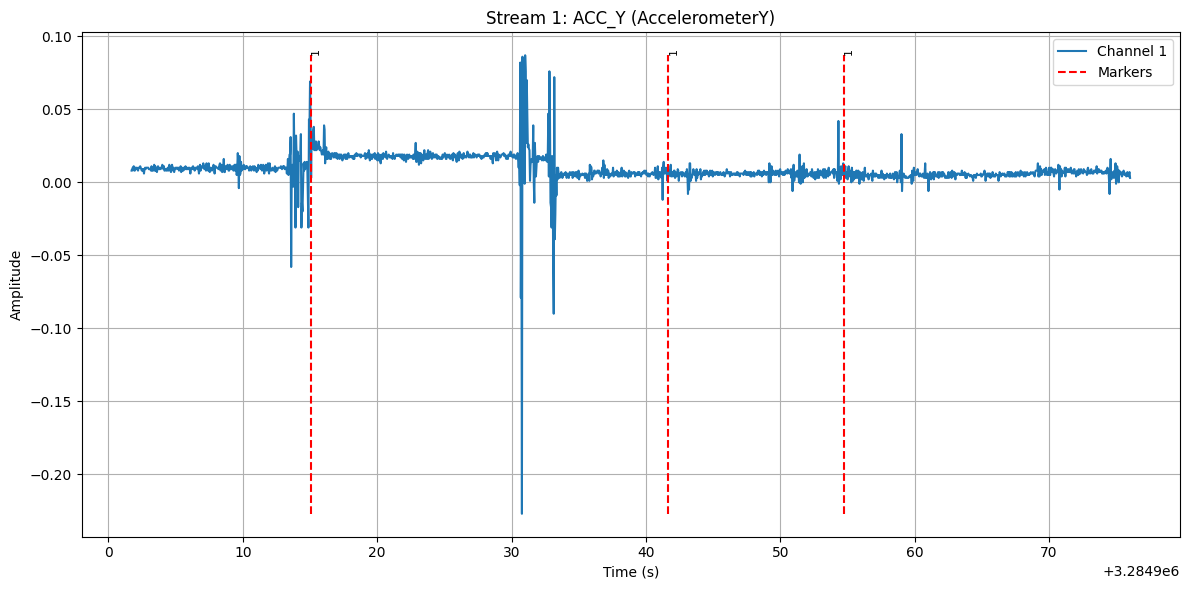

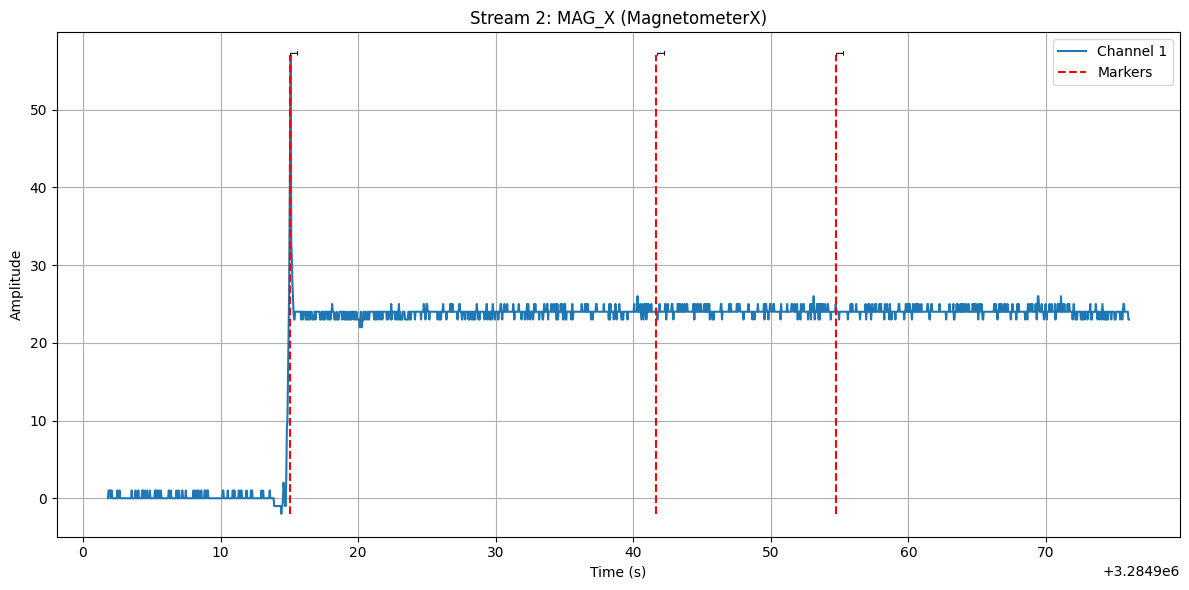

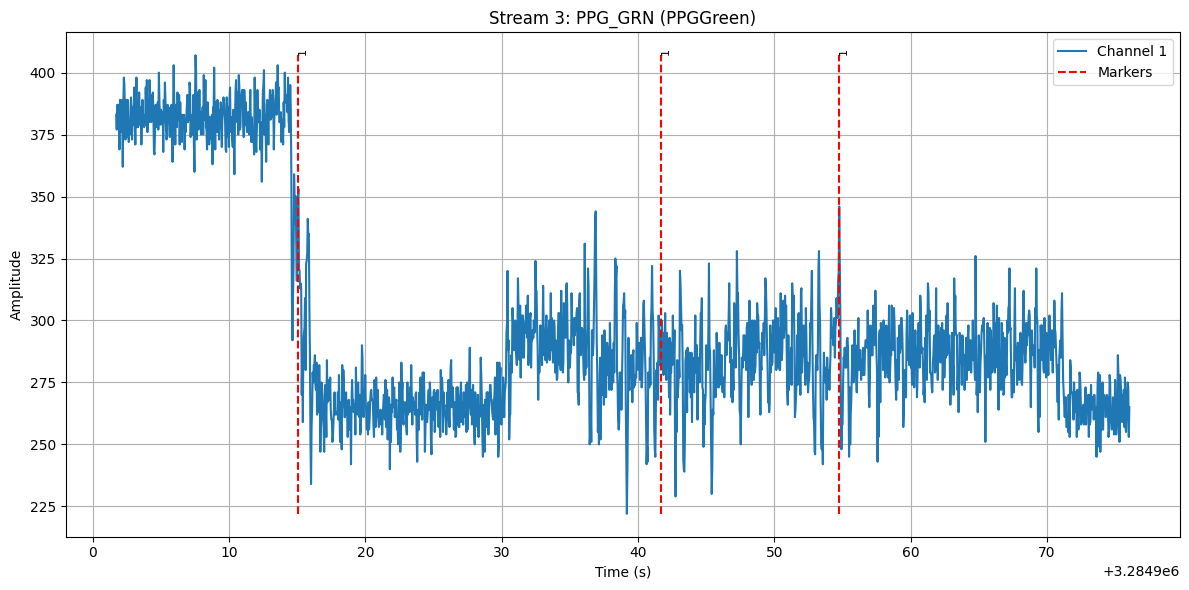

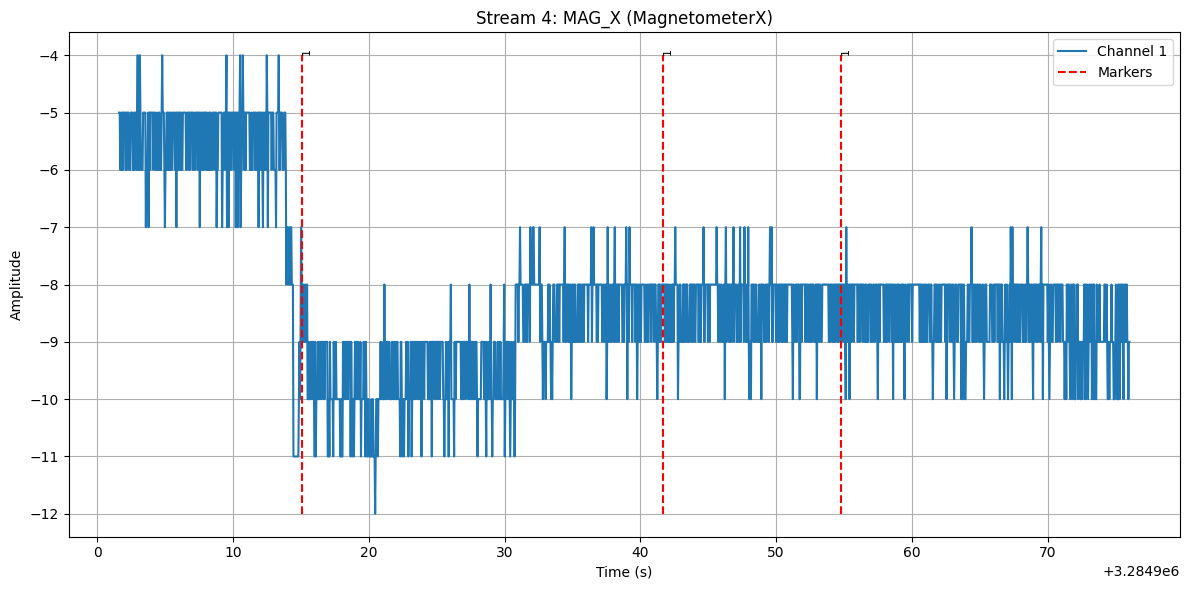

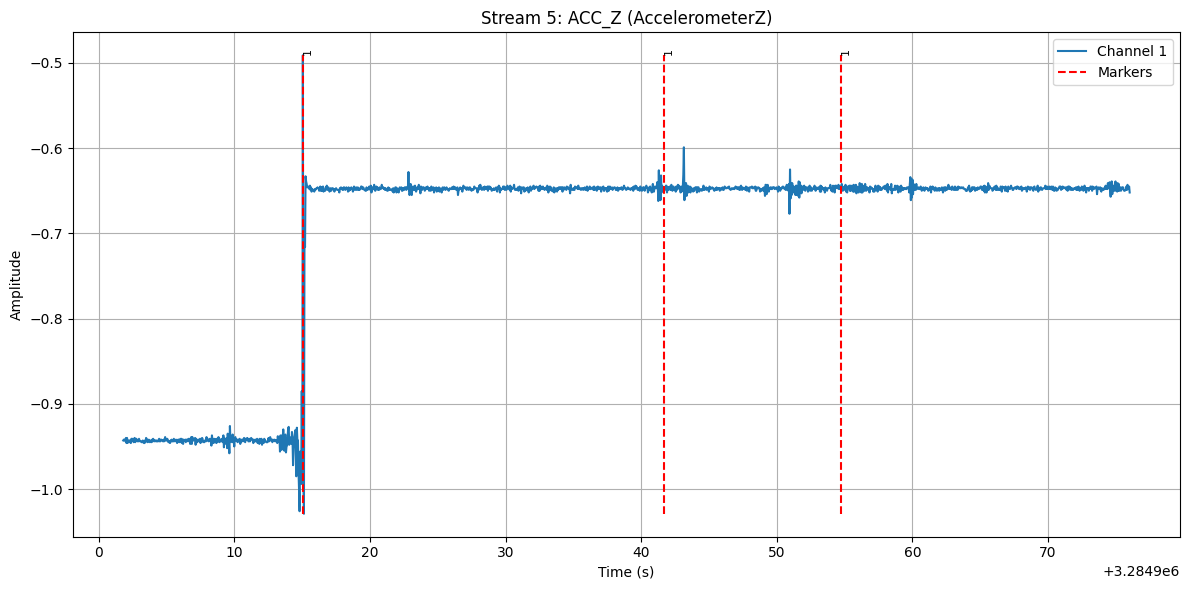

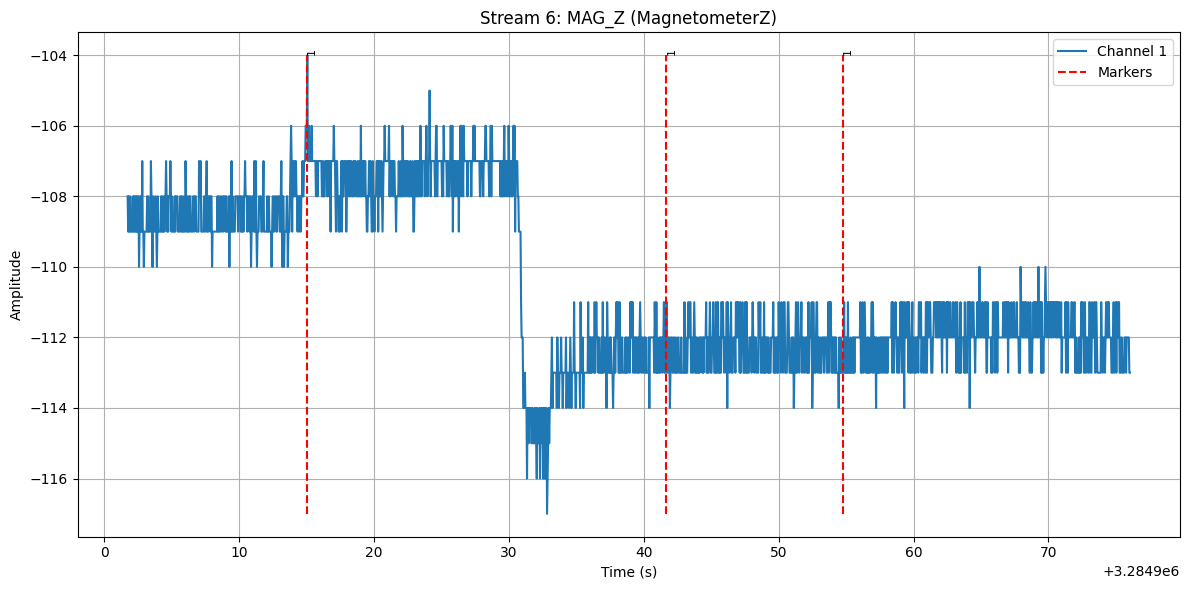

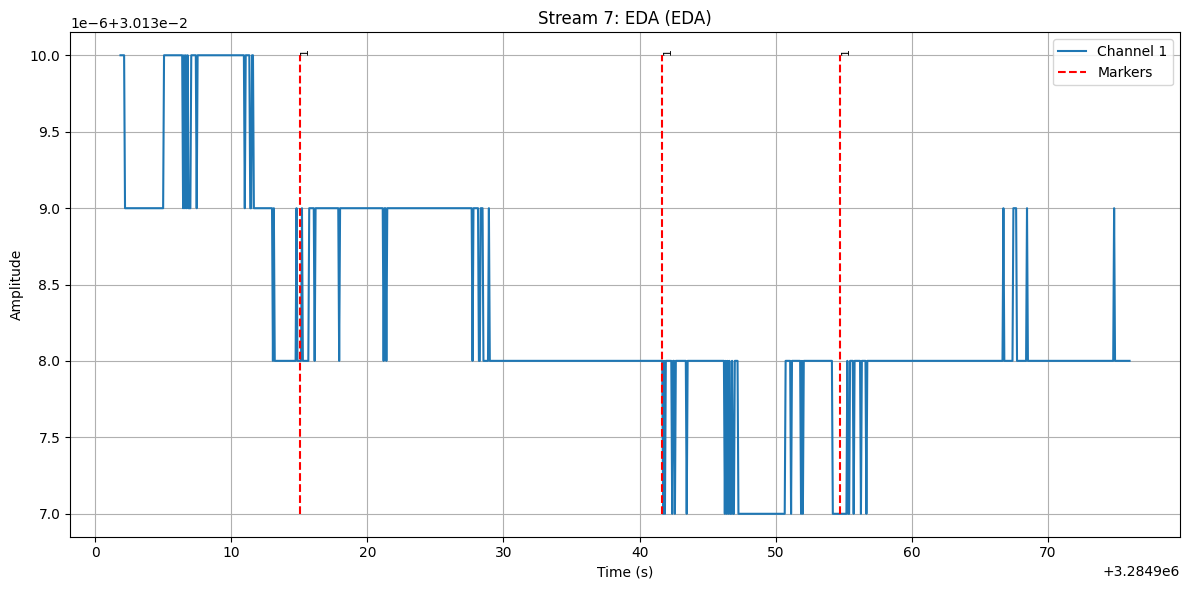

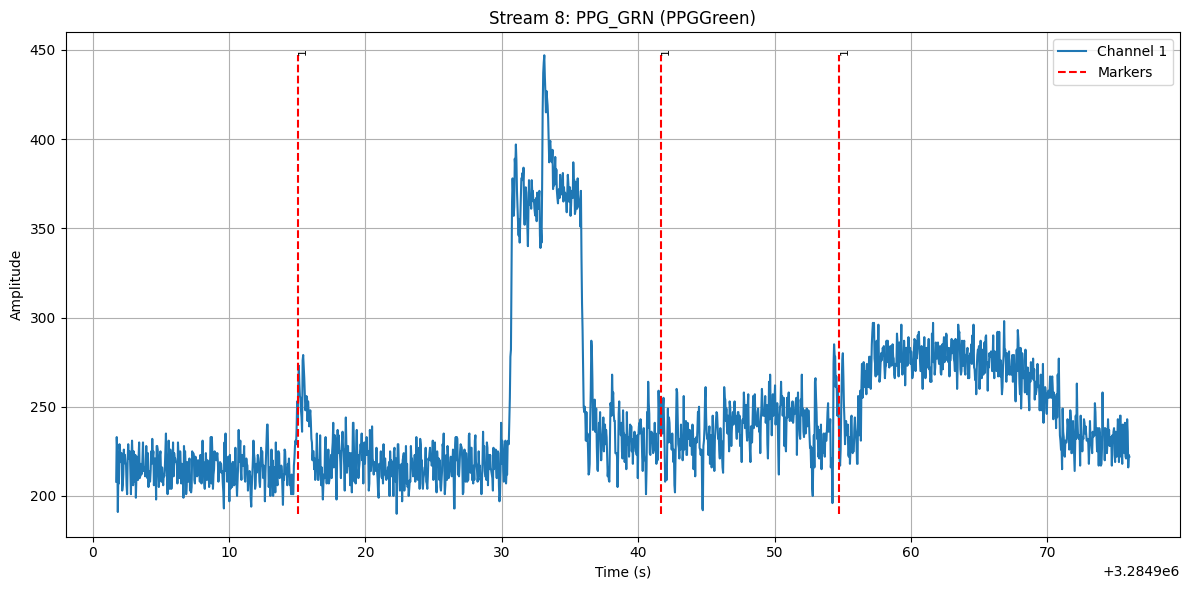

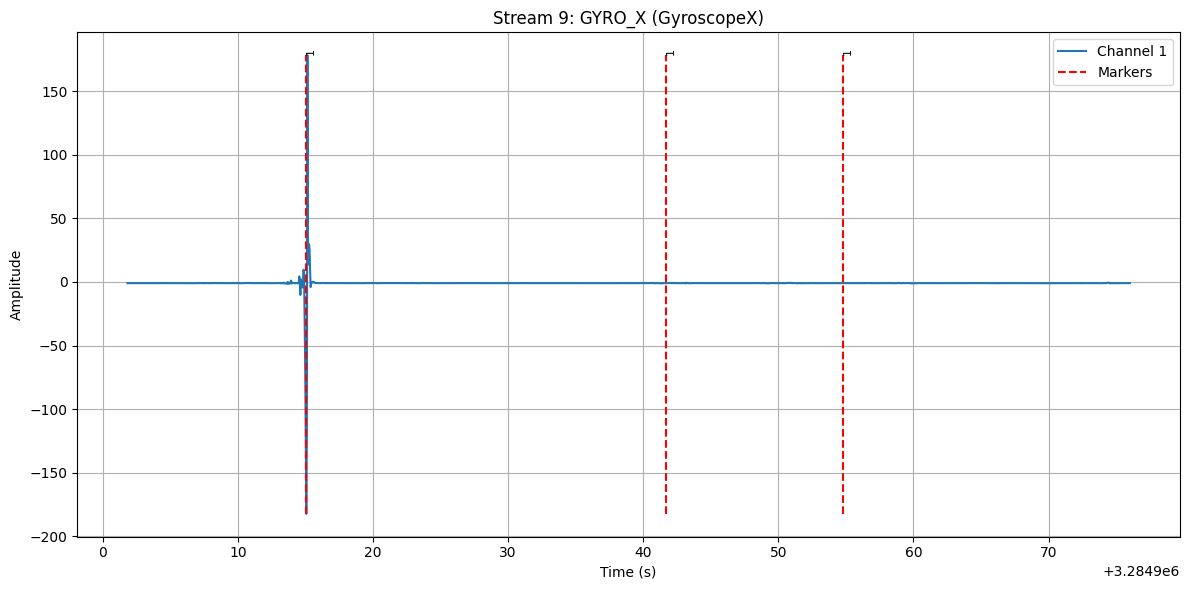

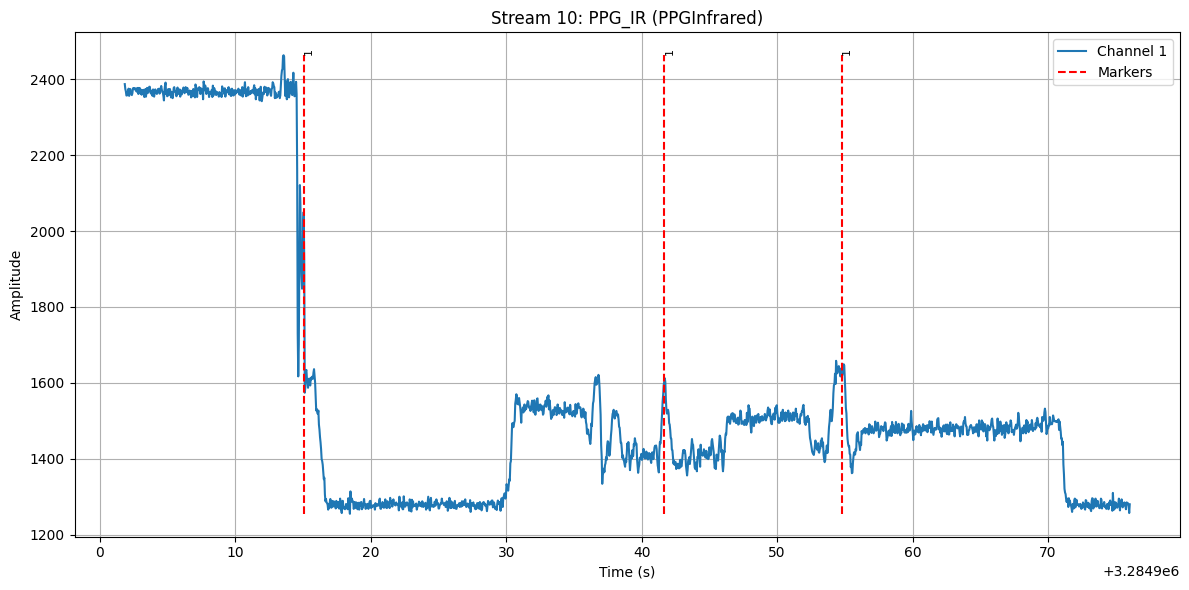

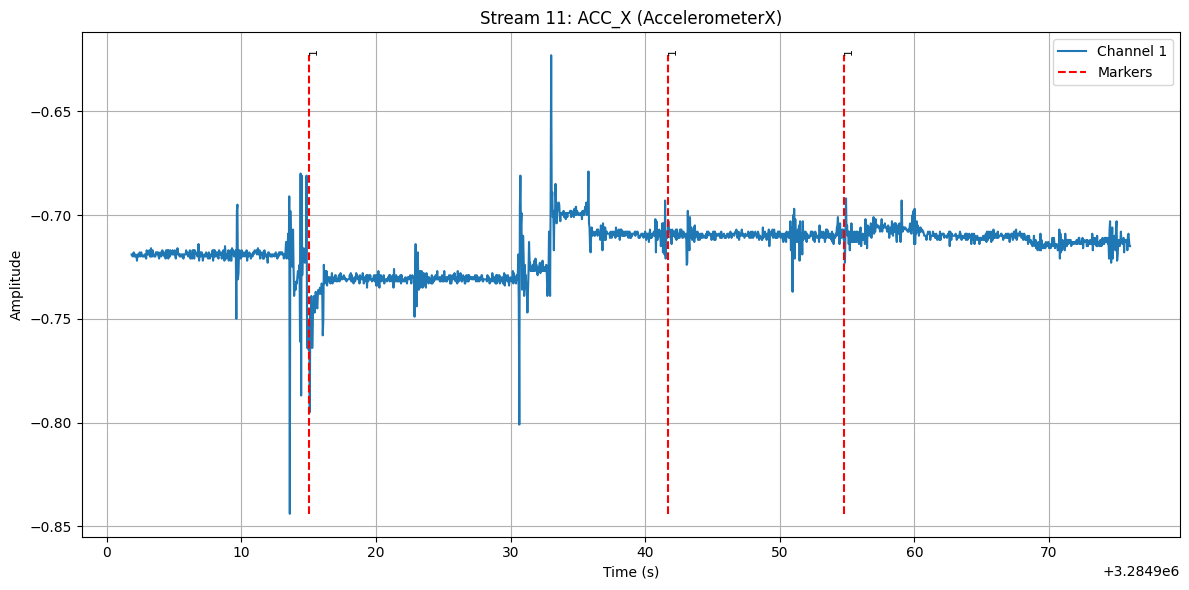

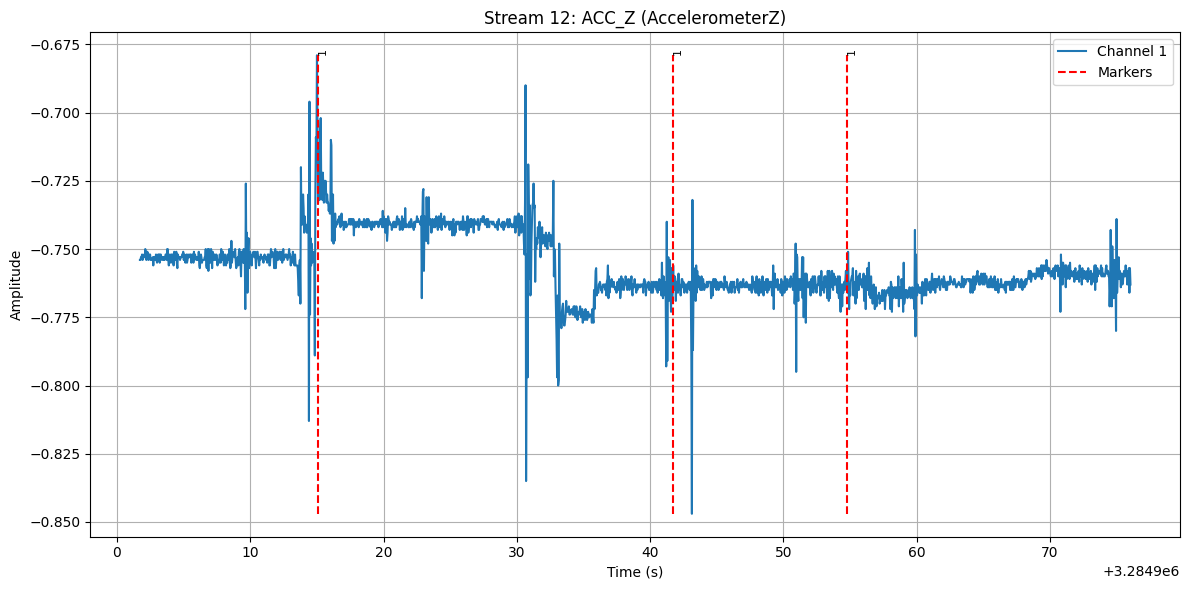

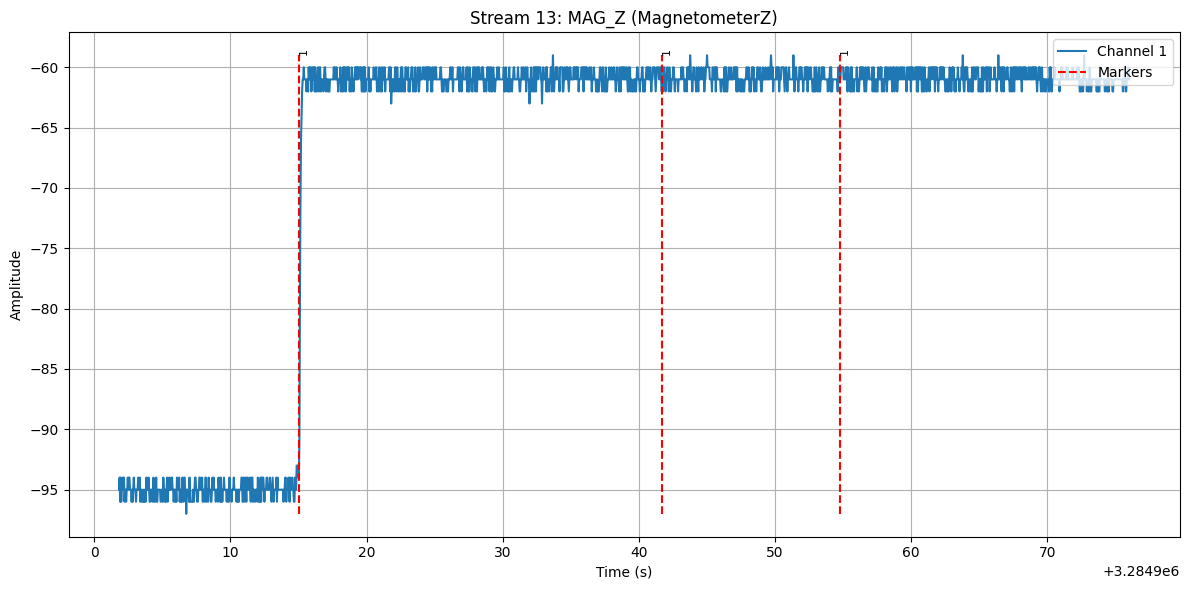

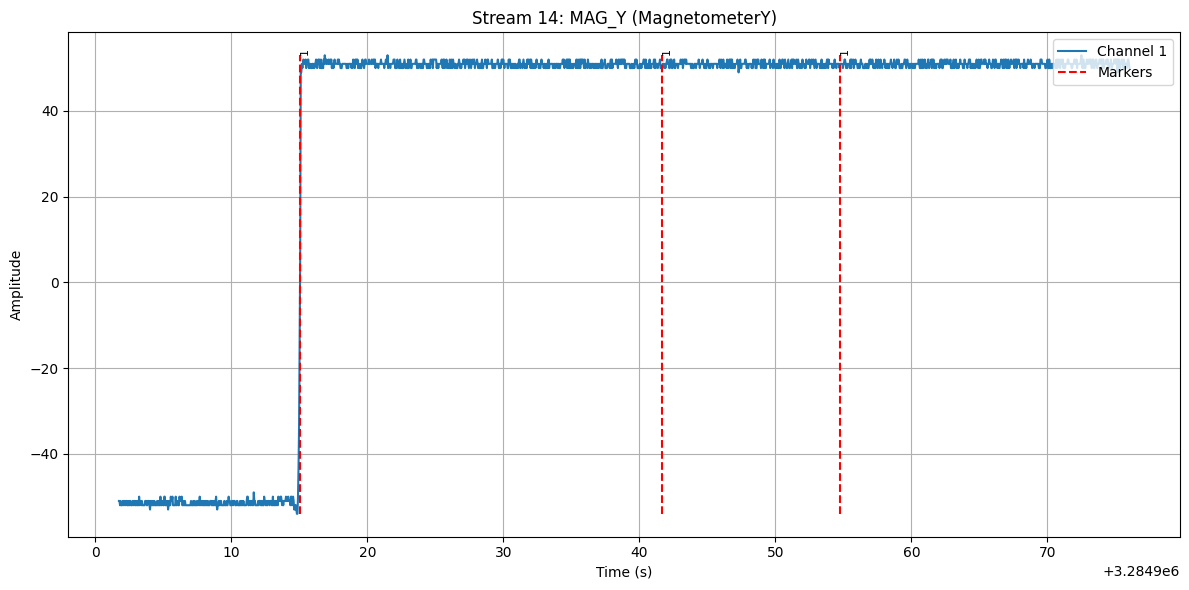

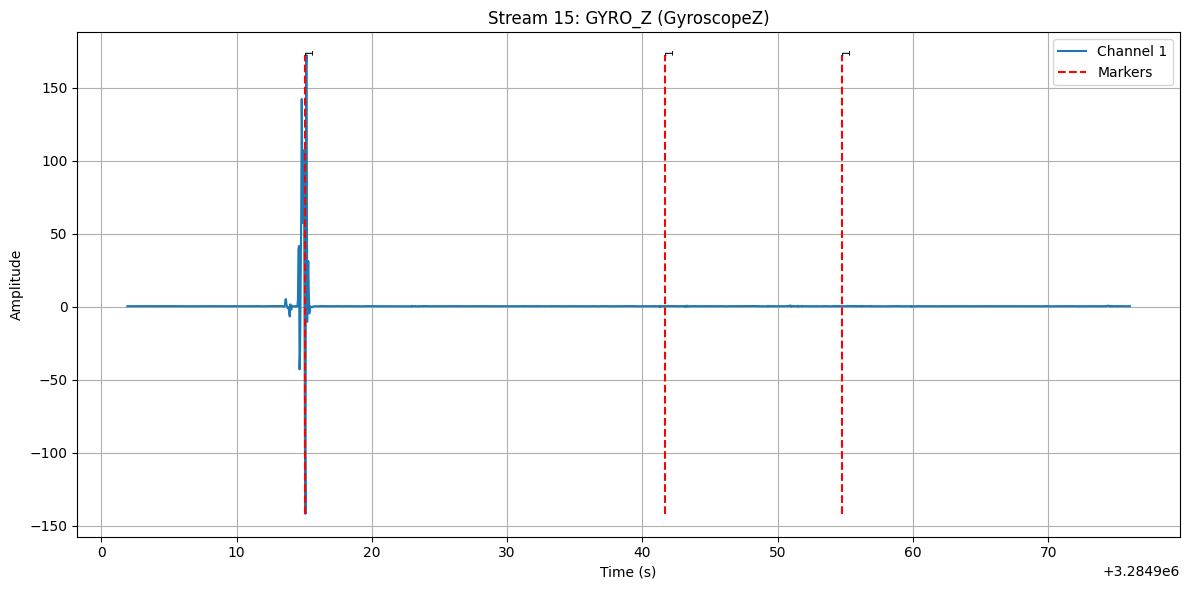

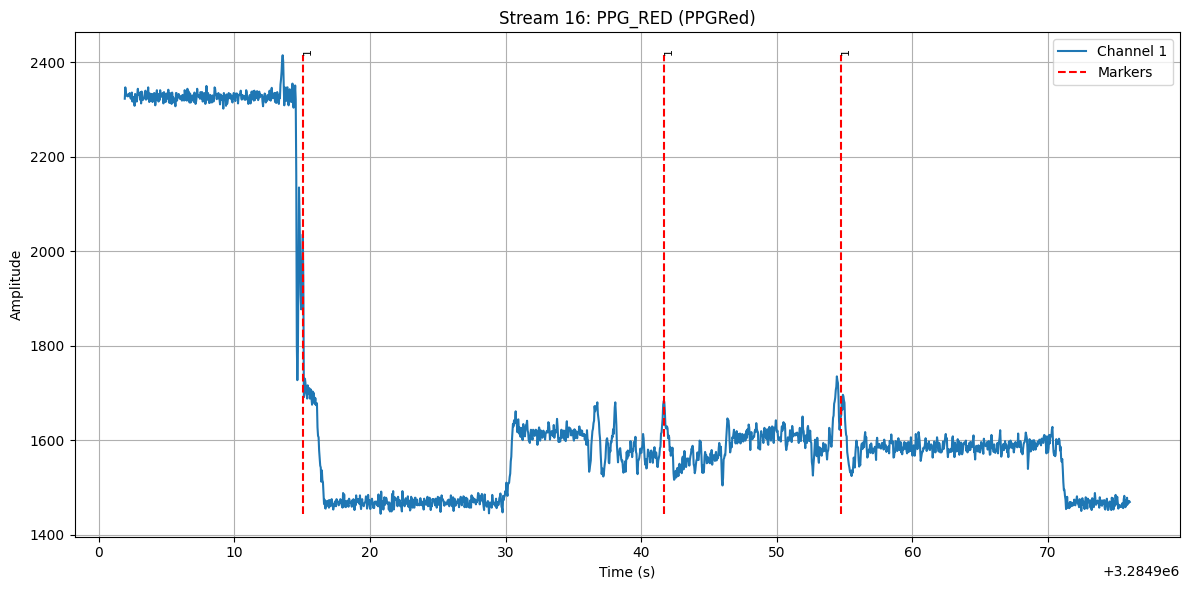

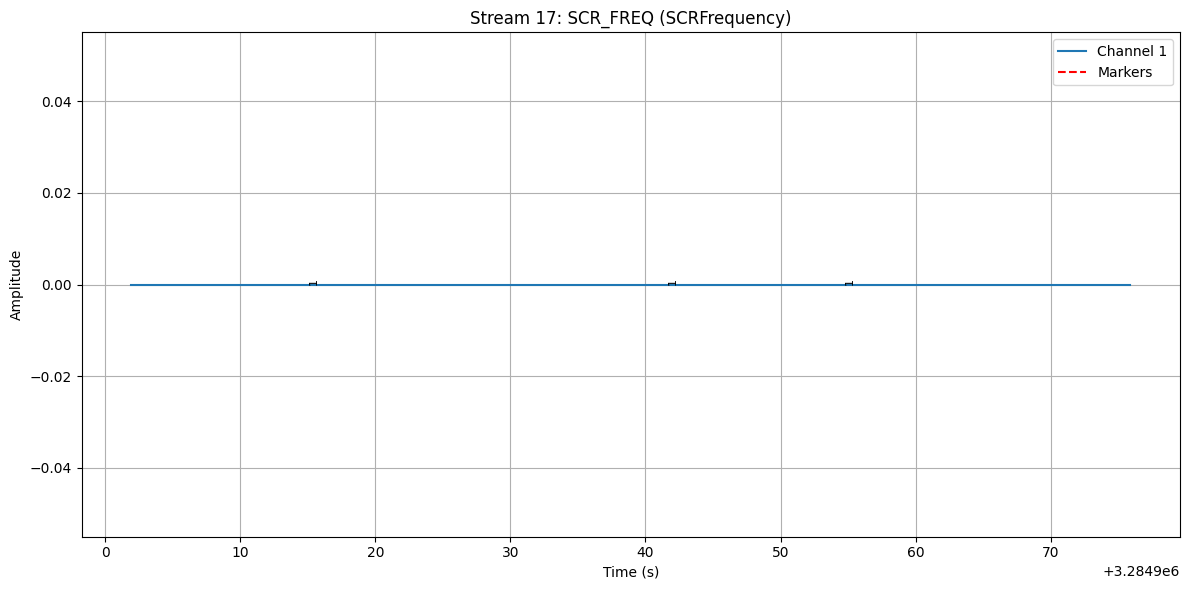

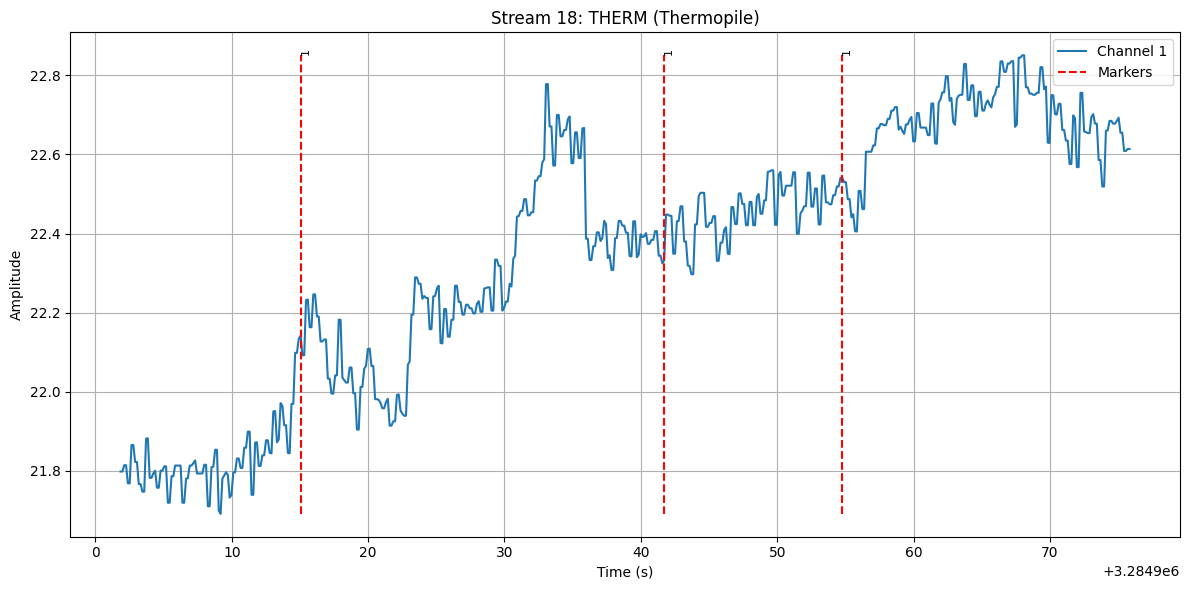

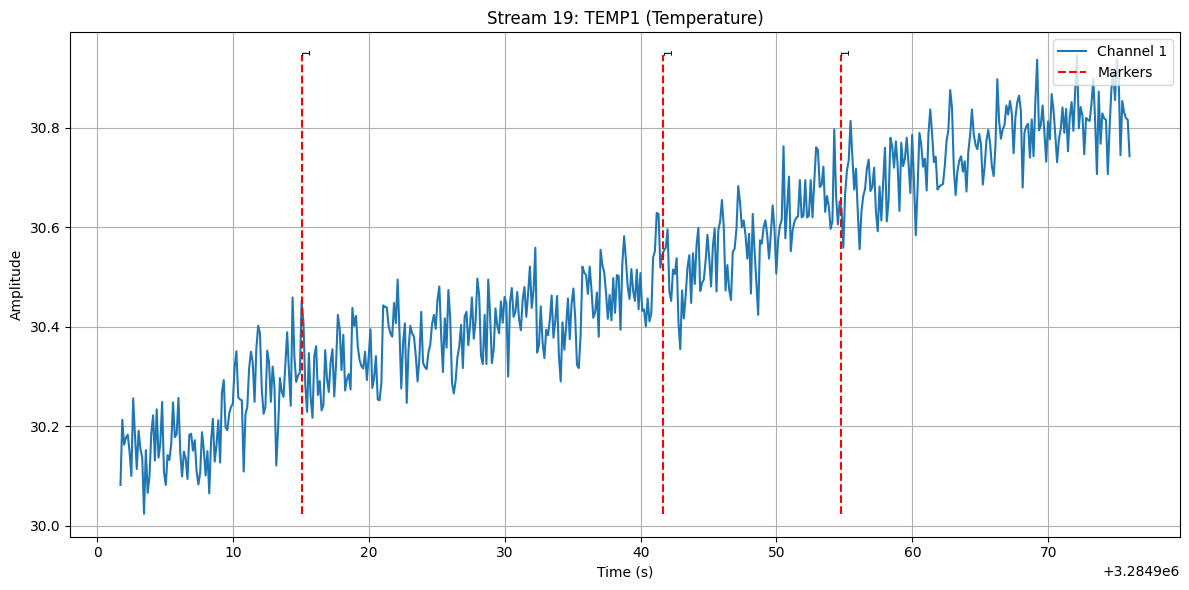

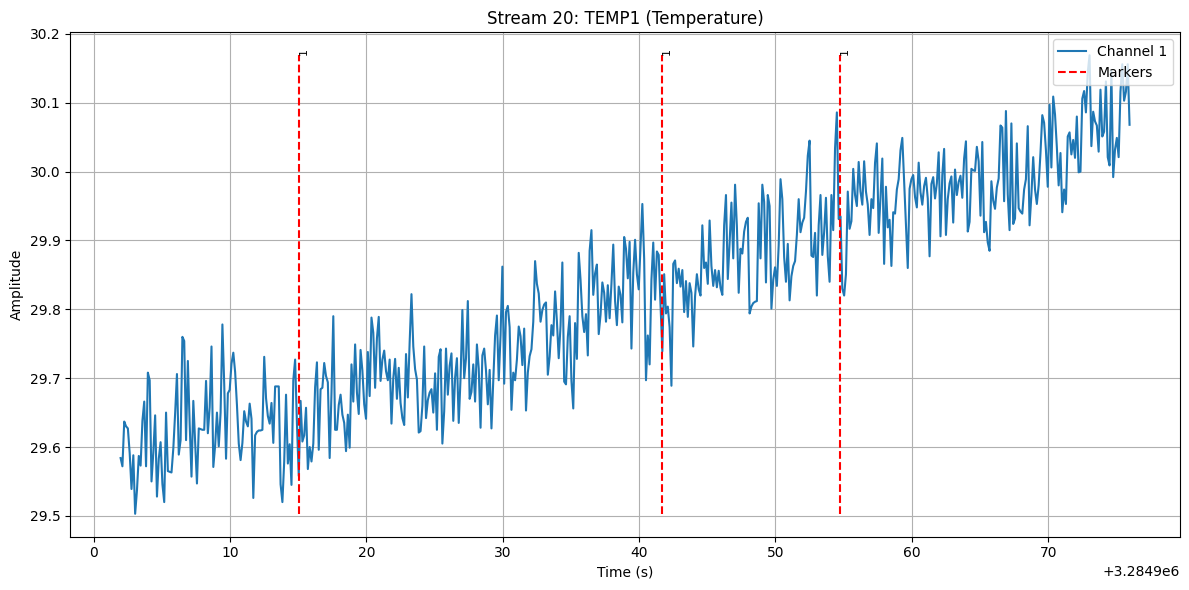

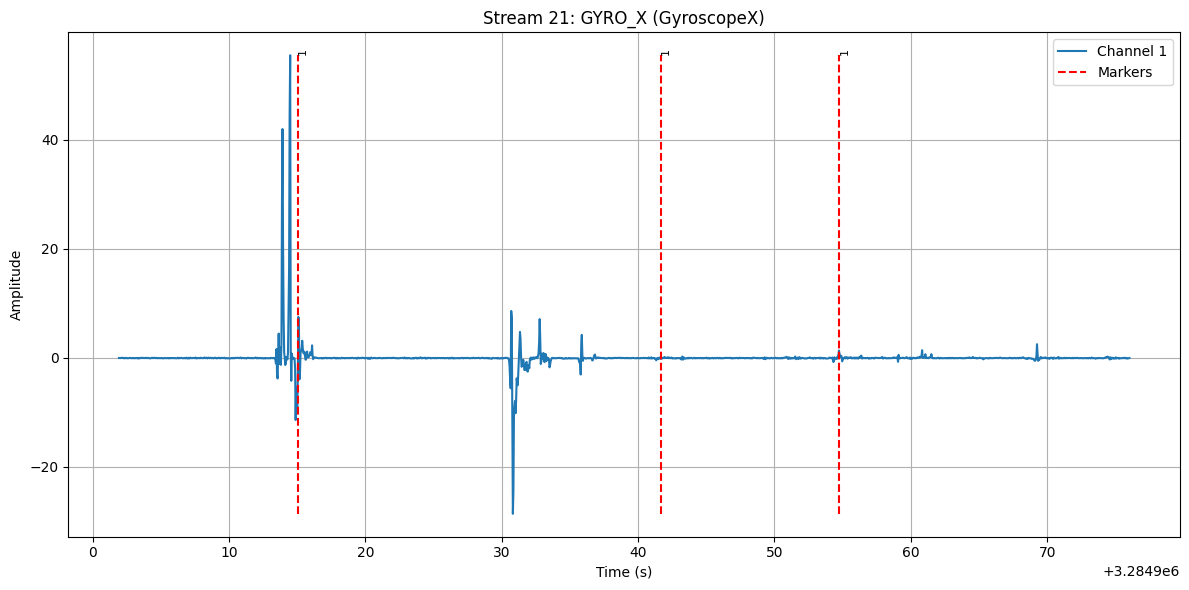

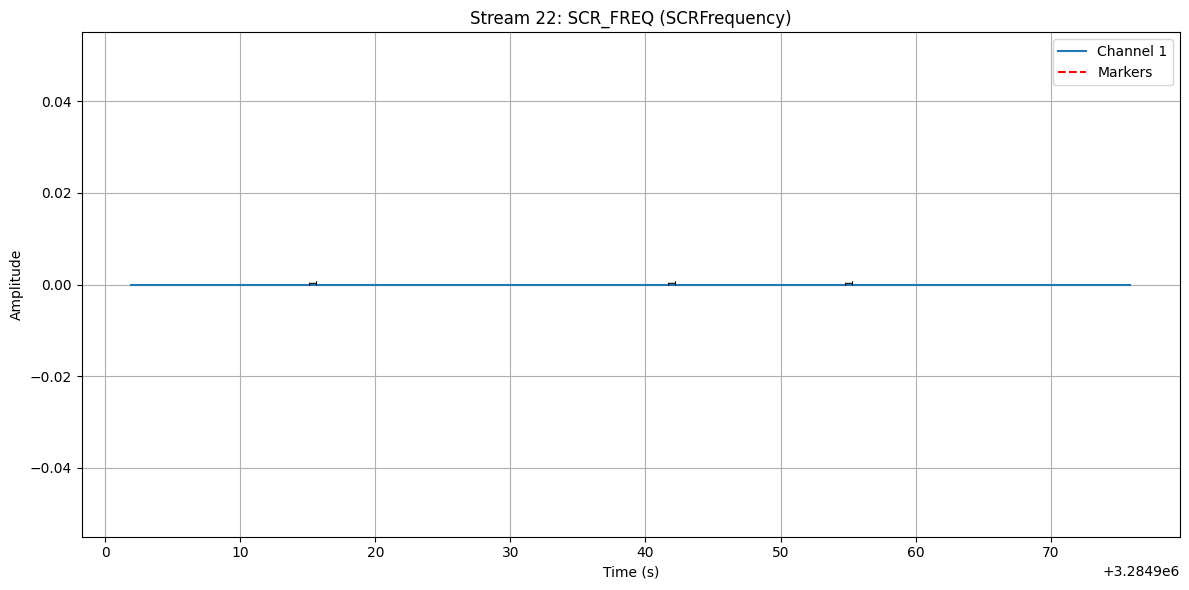

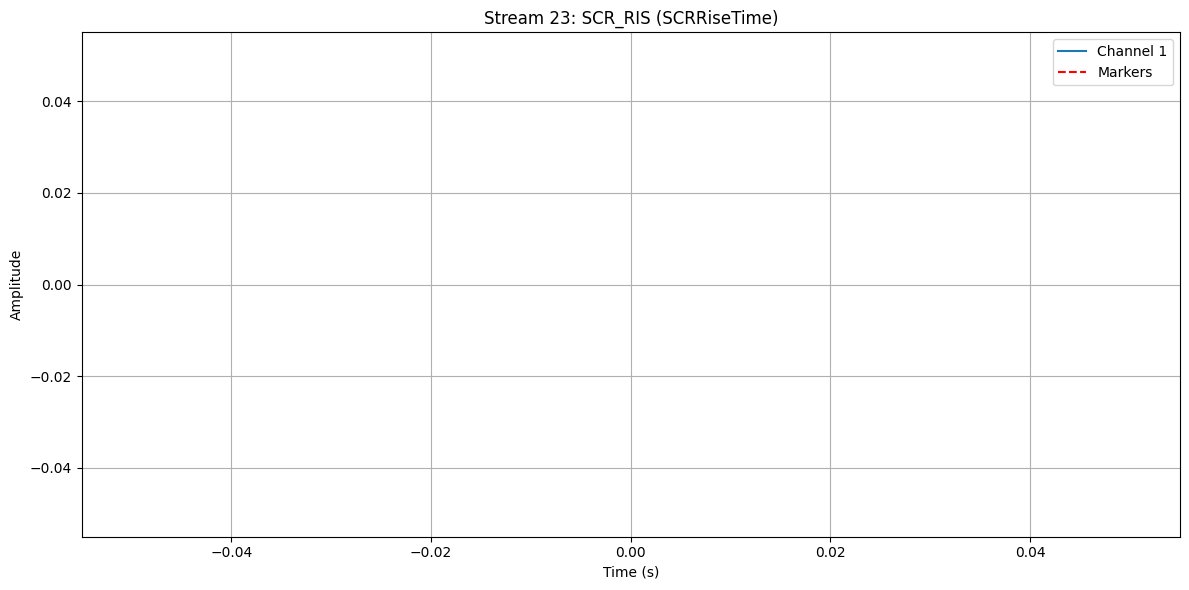

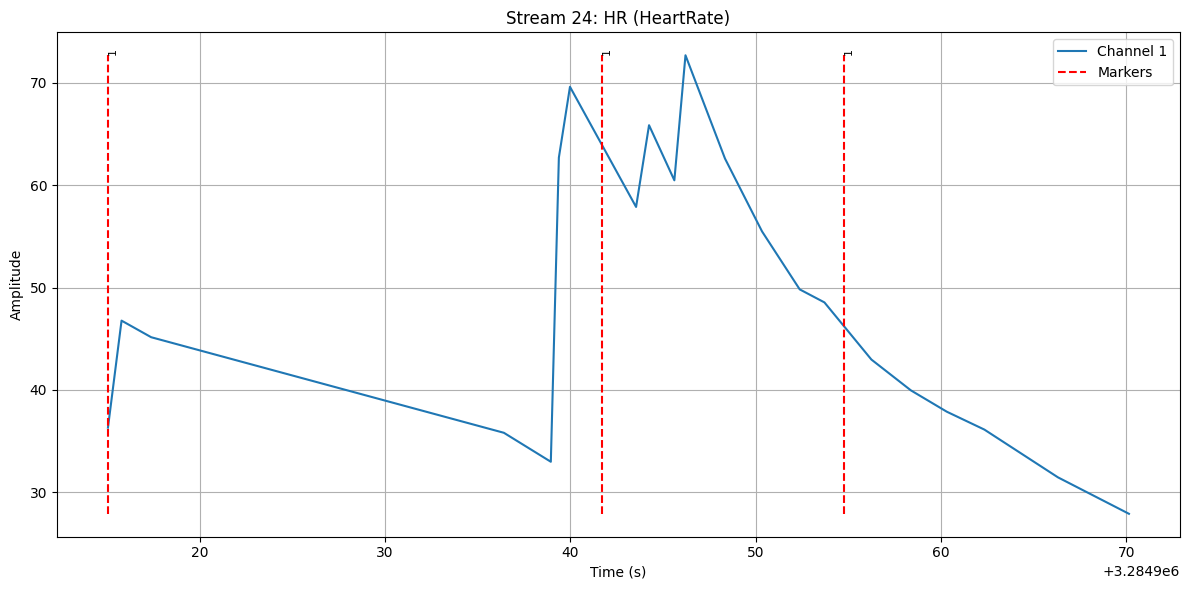

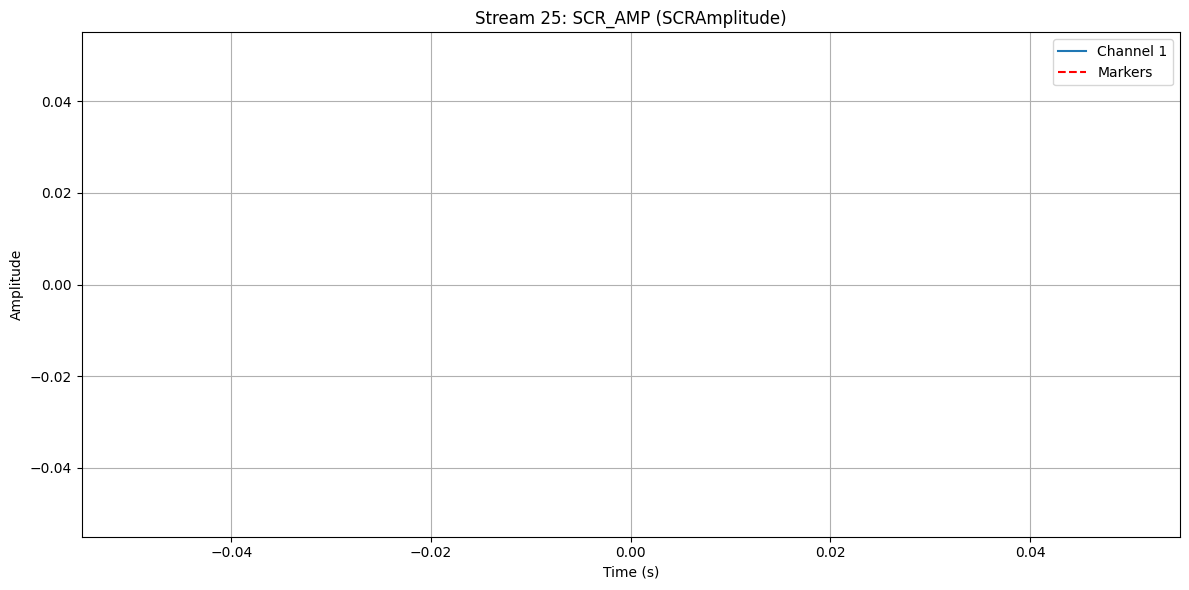

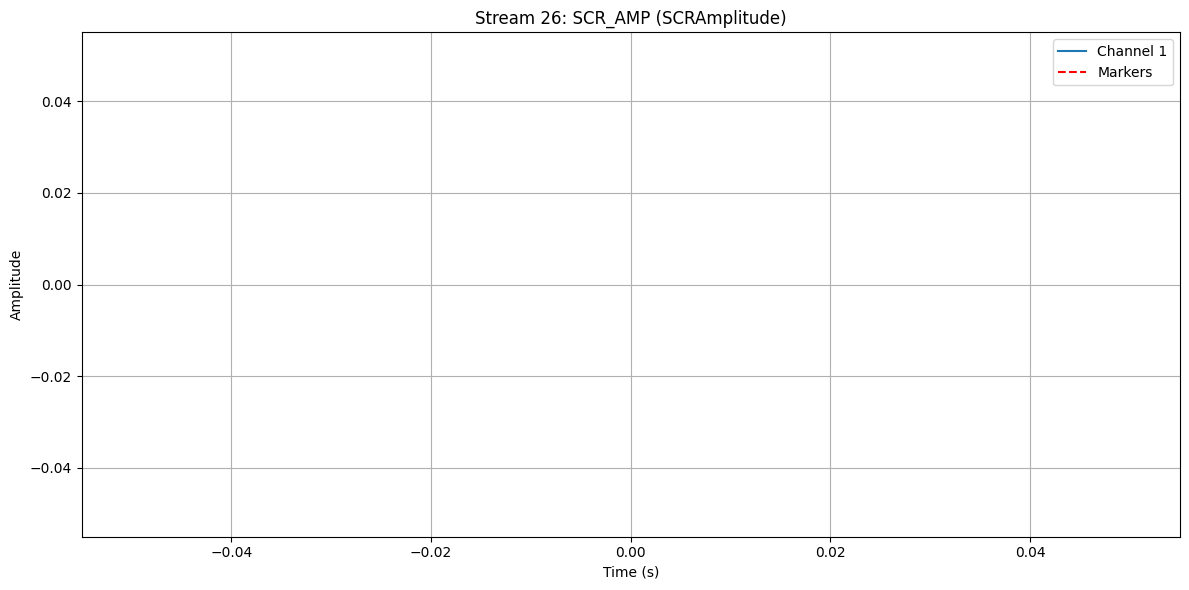

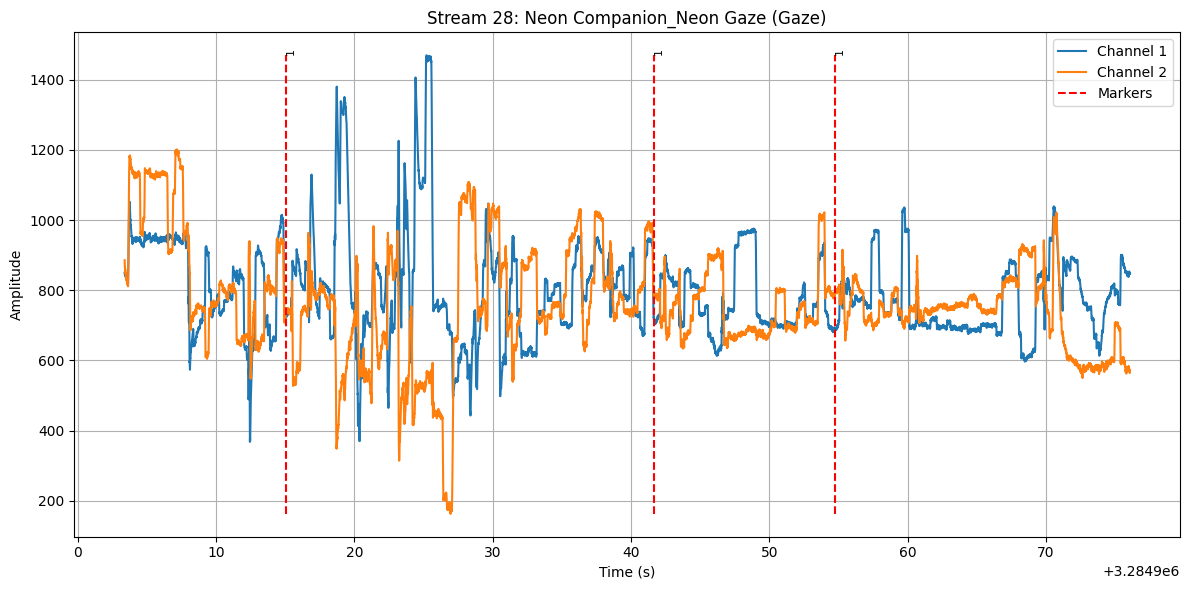

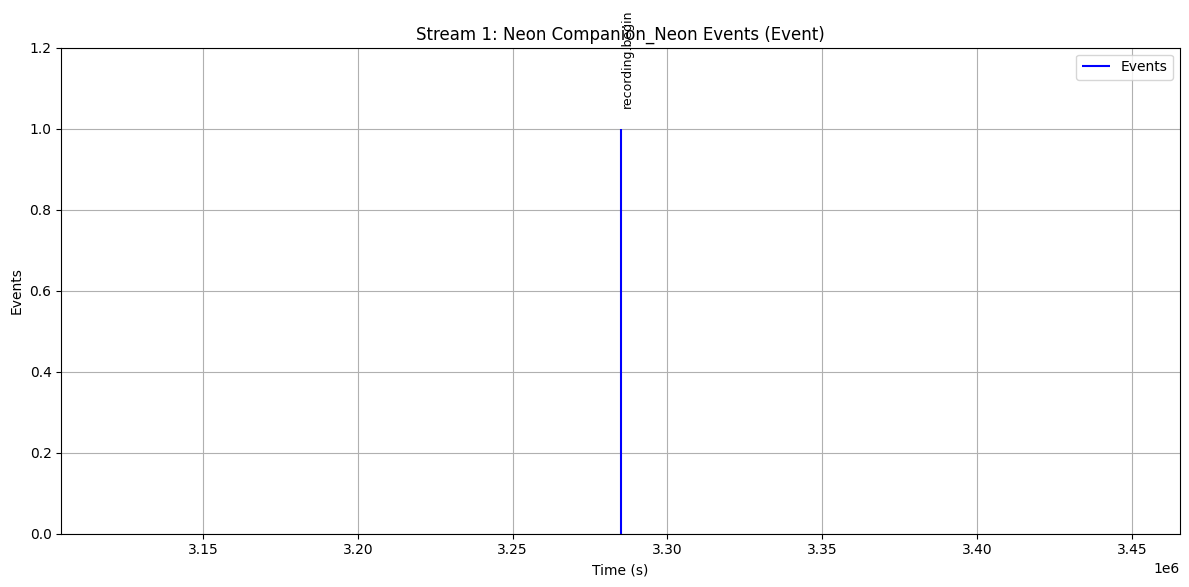

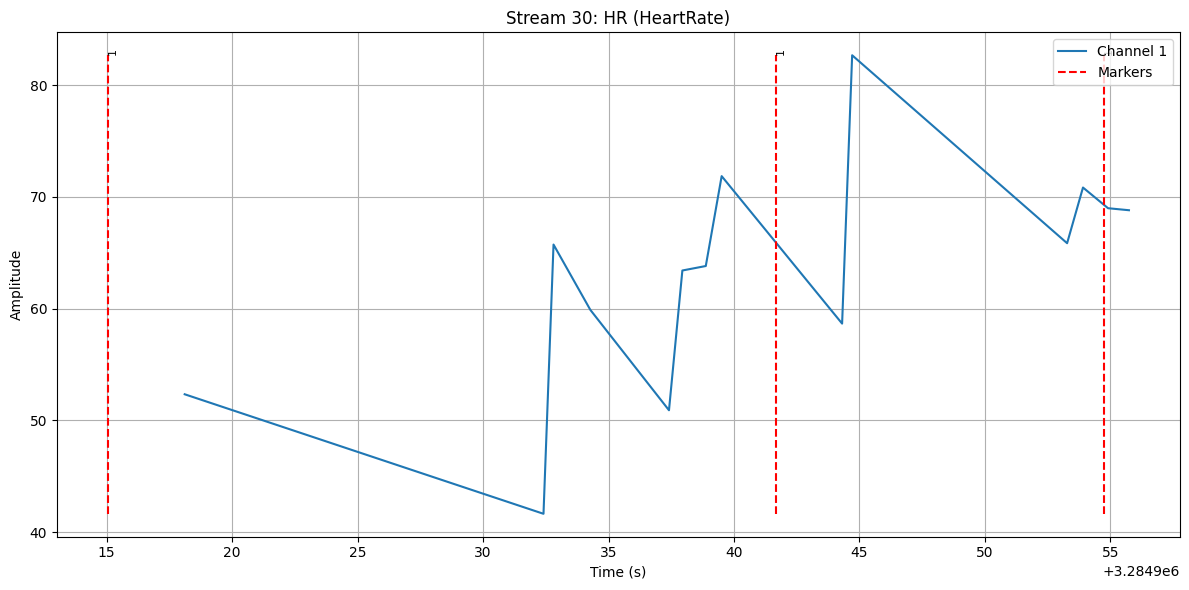

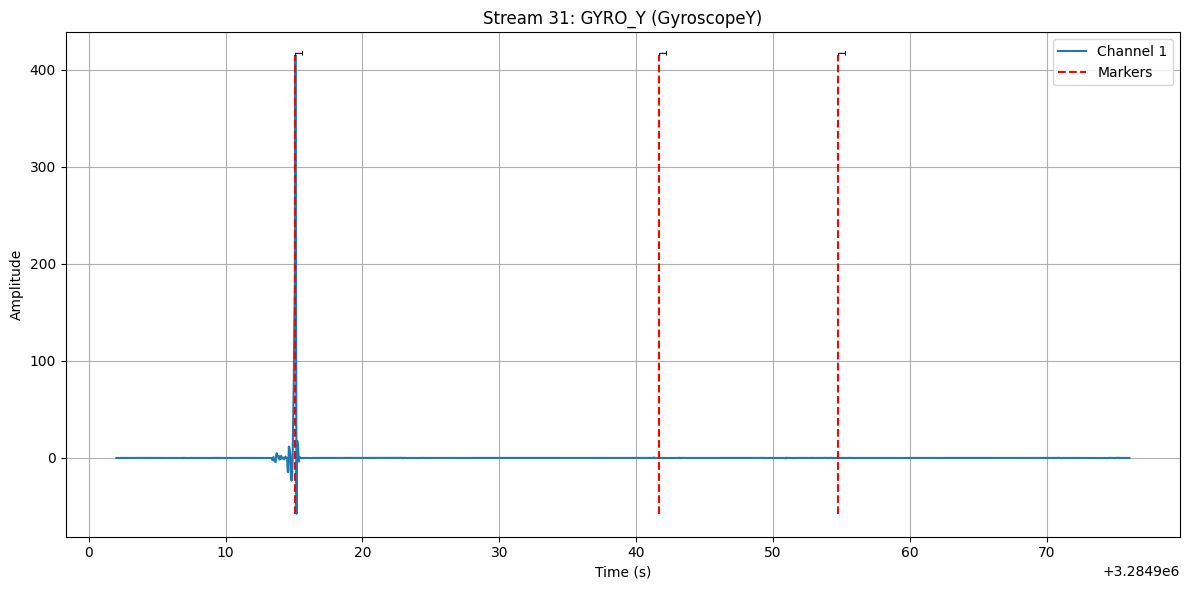

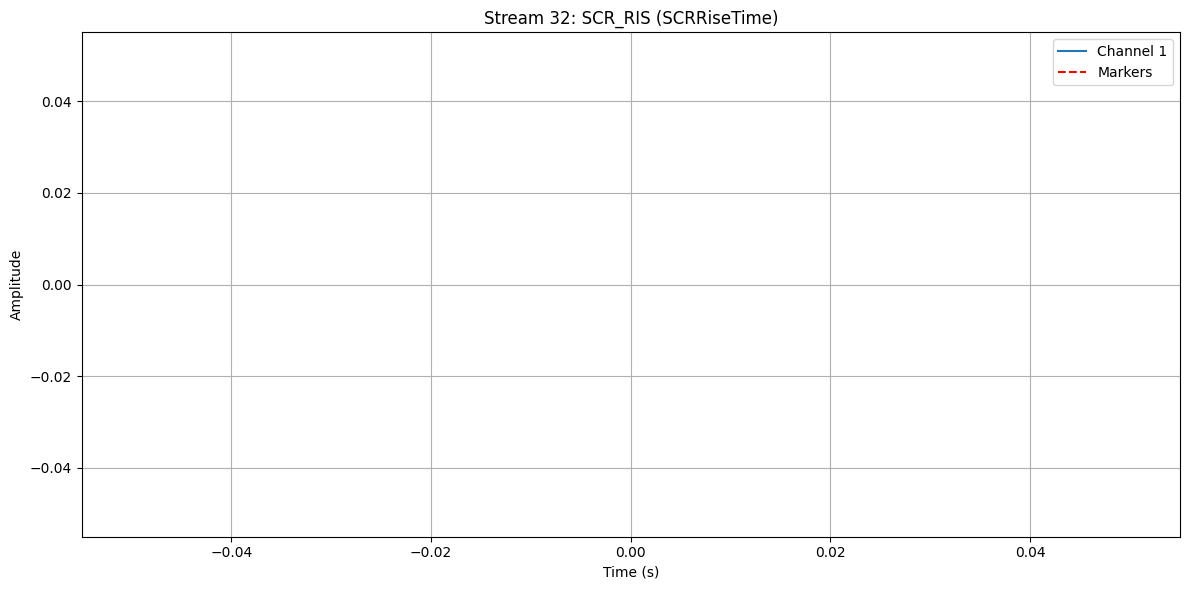

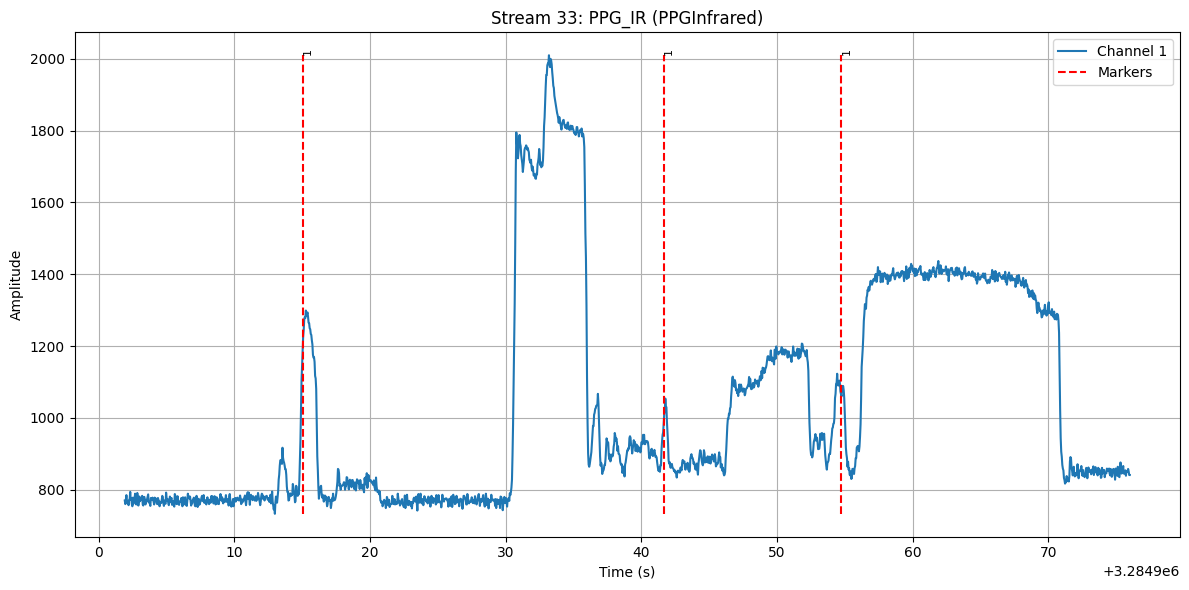

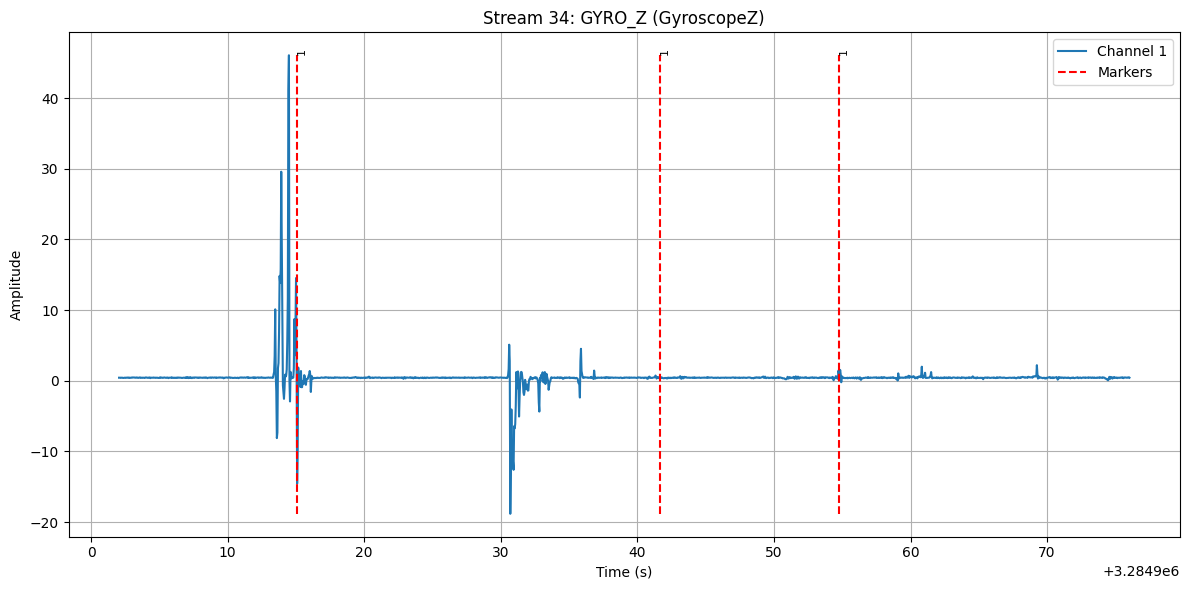

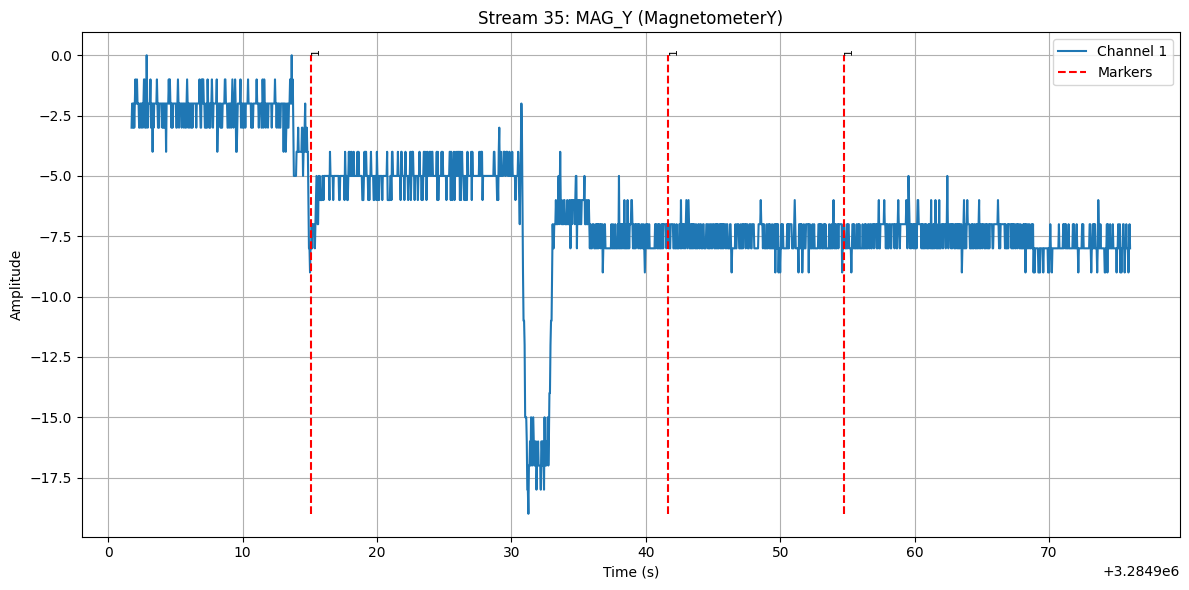

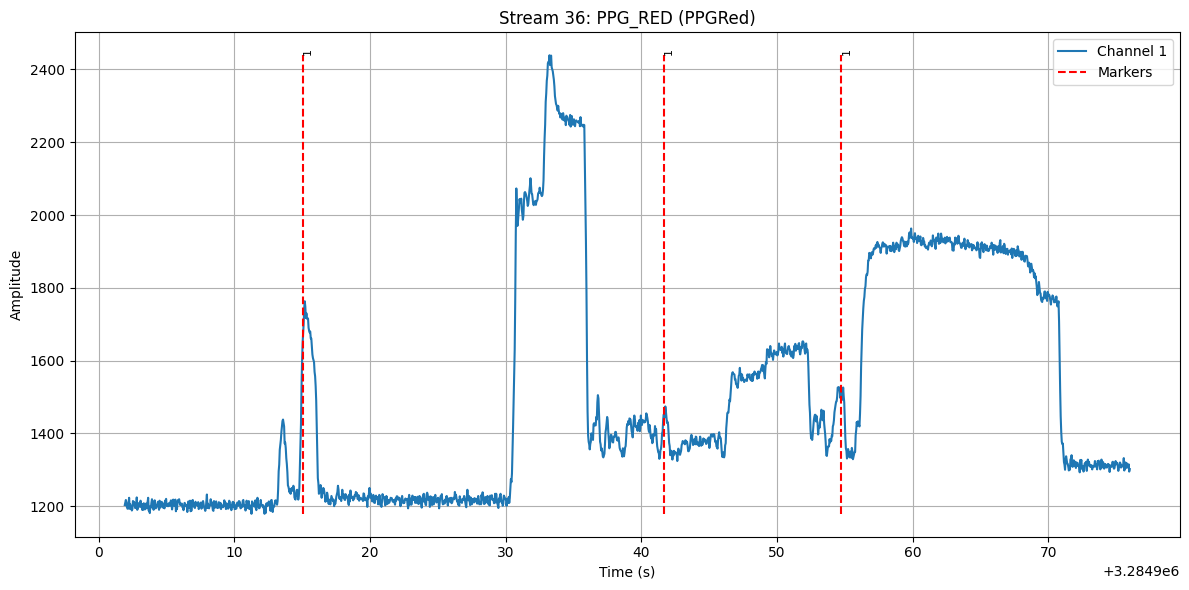

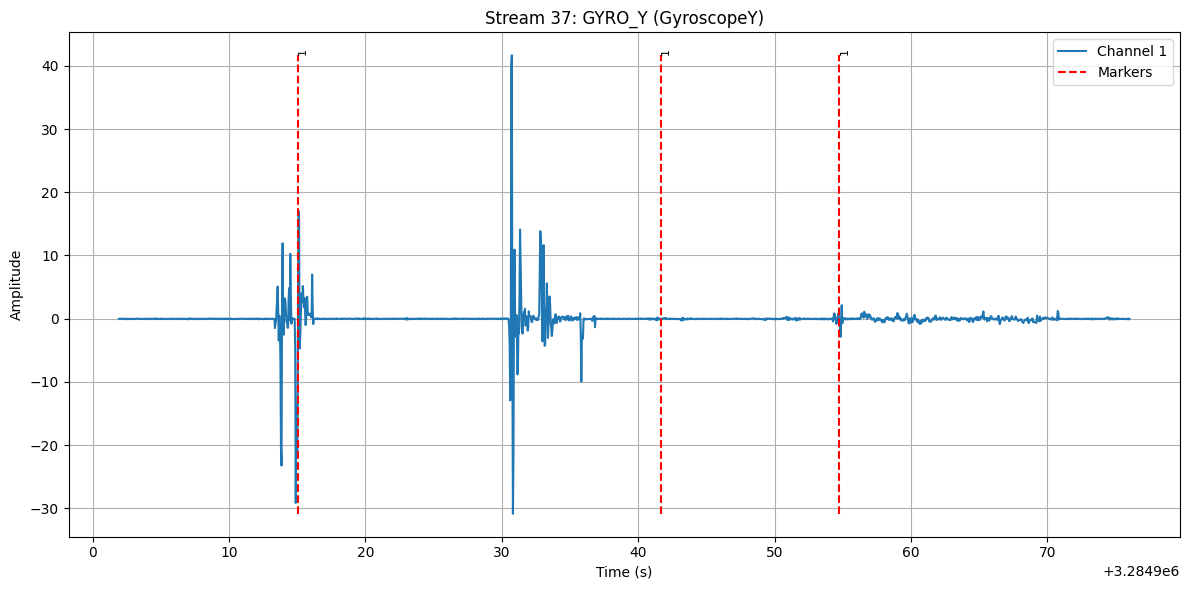

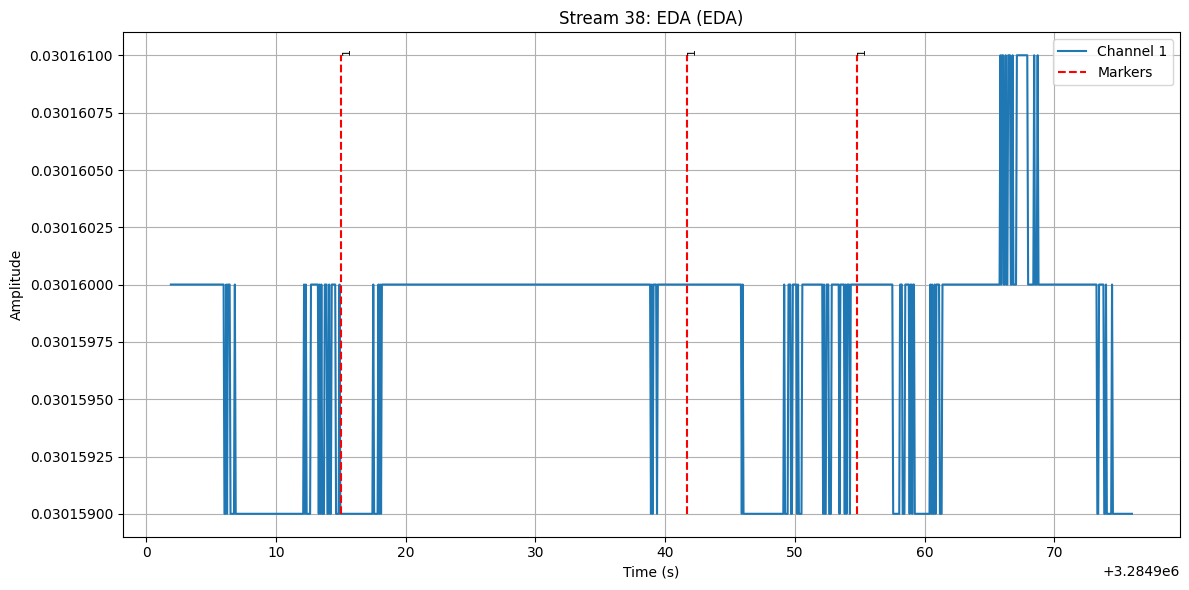

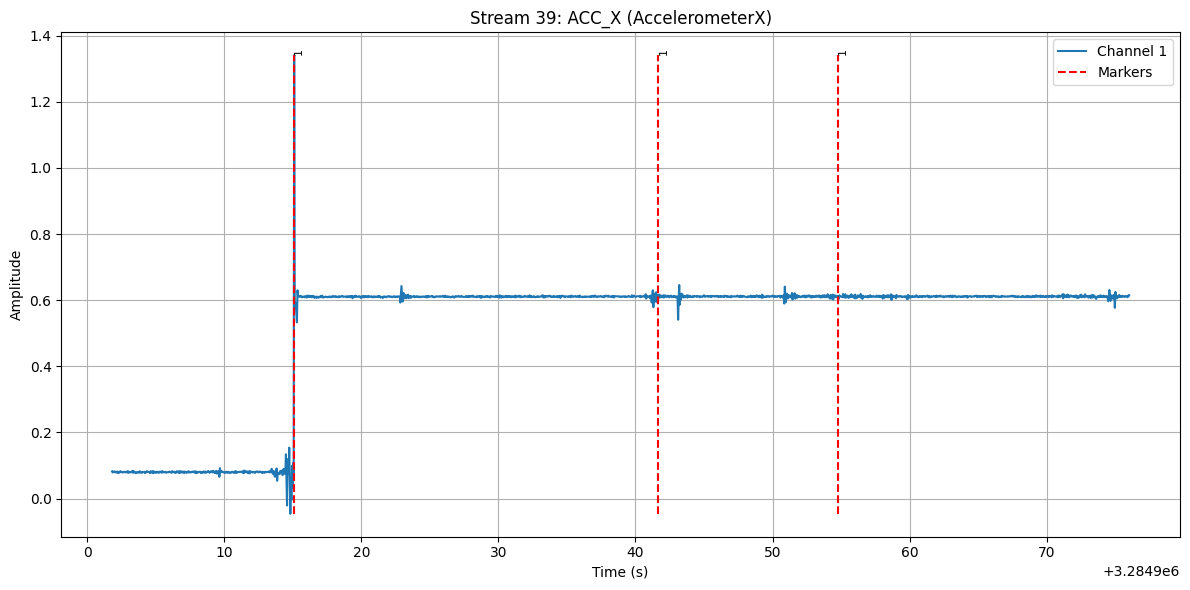

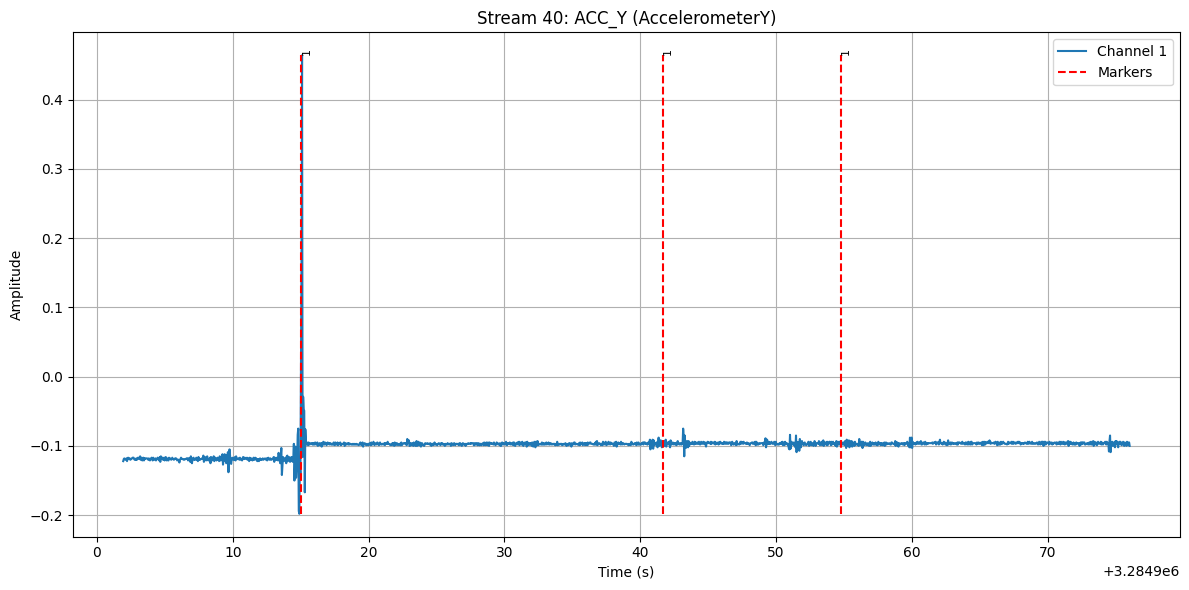

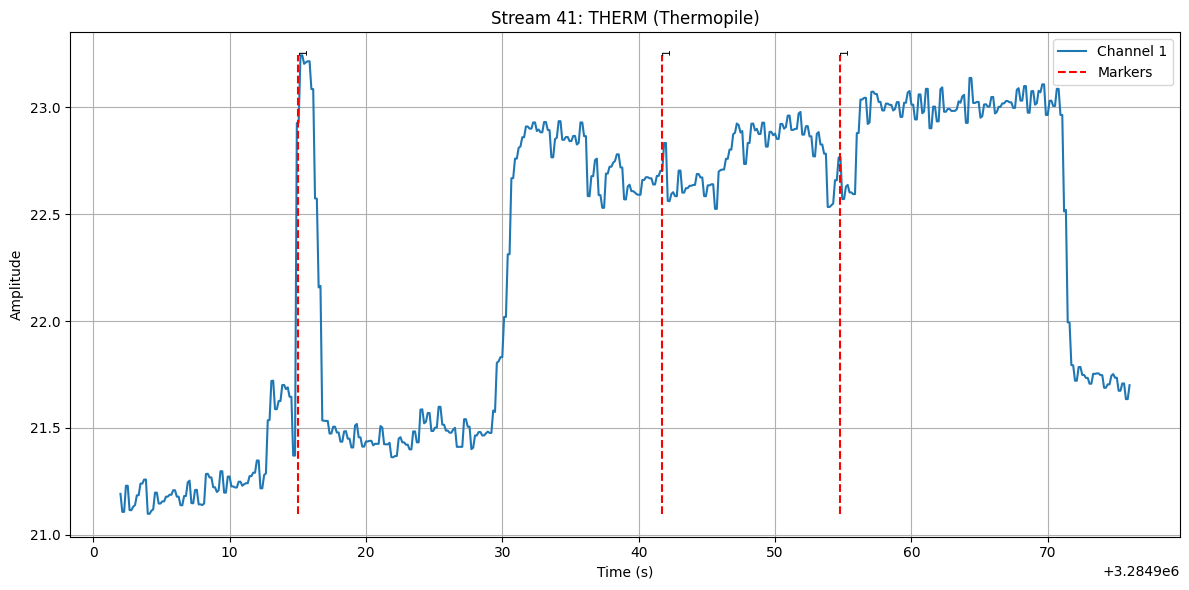

In [16]:
# Visualize all streams with the marker stream
for idx, stream in enumerate(streams):
    # Skip the marker stream to avoid redundancy
    if stream == marker_stream:
        continue

    # Extract data and timestamps for the current stream
    stream_name = stream['info']['name'][0]
    stream_type = stream['info']['type'][0]
    data = stream['time_series']
    timestamps = stream['time_stamps']
    
    # Handle list-based data
    if isinstance(data, list):
        # Create a DataFrame for discrete (list-based) data
        df = pd.DataFrame({
            "Timestamps": timestamps,
            "Events": [d[0] if isinstance(d, list) else d for d in data]  # Flatten if necessary
        })

        # Plot discrete events
        plt.figure(figsize=(12, 6))
        plt.vlines(df['Timestamps'], ymin=0, ymax=1, color='blue', linestyles='solid', label='Events')
        
        # Annotate the events
        for idx, row in df.iterrows():
            plt.text(row['Timestamps'], 1.05, row['Events'], rotation=90, fontsize=9, verticalalignment='bottom')
        
        plt.title(f"Stream {idx + 1}: {stream_name} ({stream_type})")
        plt.xlabel("Time (s)")
        plt.ylabel("Events")
        plt.ylim(0, 1.2)
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()
    else:
        # Handle numerical (array-based) data
        df = pd.DataFrame(data, columns=[f"Channel {i+1}" for i in range(data.shape[1])])
        df['Timestamps'] = timestamps

        # Plot the stream data
        plt.figure(figsize=(12, 6))
        for channel in df.columns[:-1]:  # Skip the Timestamps column
            plt.plot(df['Timestamps'], df[channel], label=channel)

        # Add the marker stream as vertical lines
        plt.vlines(marker_timestamps, ymin=df.iloc[:, :-1].min().min(), ymax=df.iloc[:, :-1].max().max(), 
                   color='red', linestyles='dashed', label='Markers')

        # Annotate each marker on the timeline
        for ts, label in zip(marker_timestamps, marker_labels):
            plt.text(ts, df.iloc[:, :-1].max().max(), label, rotation=90, fontsize=8, verticalalignment='bottom')

        # Customize the plot
        plt.title(f"Stream {idx + 1}: {stream_name} ({stream_type})")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.legend(loc='upper right')
        plt.grid()
        plt.tight_layout()
        plt.show()